# DSB reproduction


今回は3つのモデル　ConvNextV2 Atto, 

In [1]:
# Cell 1: 学習曲線データの読み込み
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RUN_ROOT = Path("/home/nakano/server/checkpoints_dense/vision_plain/cifar10")

def natural_ckpt_key(p: Path):
    m = re.search(r"checkpoint-(\d+)", p.name)
    return int(m.group(1)) if m else -1

def load_log_history(net_name: str):
    run_dir = RUN_ROOT / net_name
    ckpt_dirs = sorted(
        [d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith("checkpoint-")],
        key=natural_ckpt_key,
    )
    latest = ckpt_dirs[-1]
    state = json.load(open(latest / "trainer_state.json"))
    entries = [e for e in state["log_history"] if "loss" in e]
    steps = np.array([e["step"] for e in entries])
    epochs = np.array([e["epoch"] for e in entries])
    losses = np.array([e["loss"] for e in entries])
    grad_norms = np.array([e.get("grad_norm", np.nan) for e in entries])
    lrs = np.array([e.get("learning_rate", np.nan) for e in entries])
    return {"steps": steps, "epochs": epochs, "loss": losses, "grad_norm": grad_norms, "lr": lrs}

logs = {net: load_log_history(net) for net in ["convnext-atto", "regnet-400mf", "swin-atto"]}
for net, d in logs.items():
    print(f"{net}: {len(d['steps'])} log points, final loss={d['loss'][-1]:.4f}")

convnext-atto: 620 log points, final loss=0.0158
regnet-400mf: 620 log points, final loss=0.8252
swin-atto: 620 log points, final loss=0.2746


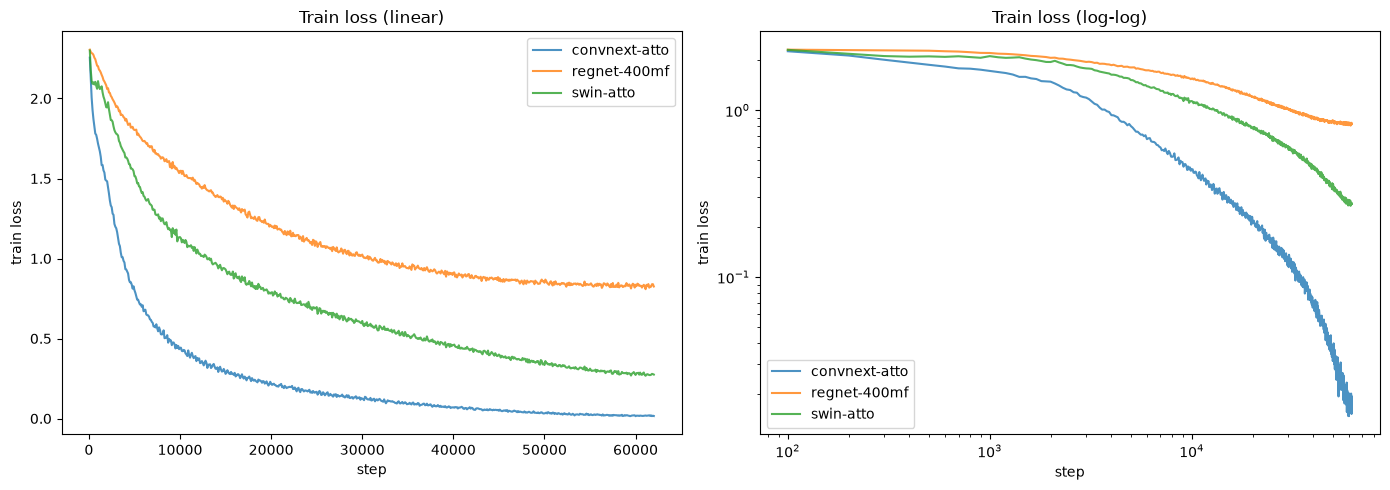

In [2]:
# Cell 2: loss推移の描画(線形スケール + logスケール)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"convnext-atto": "tab:blue", "regnet-400mf": "tab:orange", "swin-atto": "tab:green"}

for net, d in logs.items():
    axes[0].plot(d["steps"], d["loss"], label=net, alpha=0.8, color=colors[net])
    axes[1].plot(d["steps"], d["loss"], label=net, alpha=0.8, color=colors[net])

axes[0].set_xlabel("step")
axes[0].set_ylabel("train loss")
axes[0].set_title("Train loss (linear)")
axes[0].legend()

axes[1].set_xlabel("step")
axes[1].set_ylabel("train loss")
axes[1].set_yscale("log")
axes[1].set_xscale("log")
axes[1].set_title("Train loss (log-log)")
axes[1].legend()

plt.tight_layout()
plt.show()

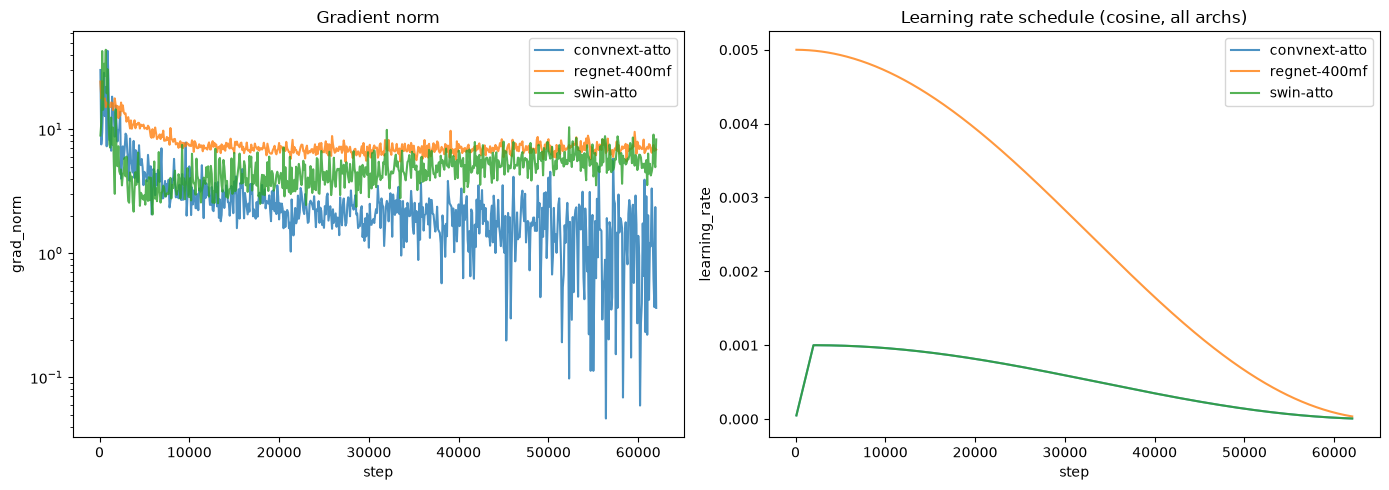

In [3]:
# Cell 3: grad_norm と learning_rate の推移
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for net, d in logs.items():
    axes[0].plot(d["steps"], d["grad_norm"], label=net, alpha=0.8, color=colors[net])
    axes[1].plot(d["steps"], d["lr"], label=net, alpha=0.8, color=colors[net])

axes[0].set_xlabel("step")
axes[0].set_ylabel("grad_norm")
axes[0].set_yscale("log")
axes[0].set_title("Gradient norm")
axes[0].legend()

axes[1].set_xlabel("step")
axes[1].set_ylabel("learning_rate")
axes[1].set_title("Learning rate schedule (cosine, all archs)")
axes[1].legend()

plt.tight_layout()
plt.show()